### Read-in downloaded data

In [1]:
import os
import logging
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs

In [2]:
class UserModel(tf.keras.Model) :

    def __init__(self, conf):
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_genders'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_genders']) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                 vocabulary=conf['unique_langs'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_langs']) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_countries'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_countries']) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_networks'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_networks']) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])

        self.centroids = tf.constant(
            [
                [36.68147669256268, -82.8910274009993],
                [23.22243322909555, 78.23027450833709],
                [50.04997682638993, 0.22379313938744885],
                [37.9309447099281, -117.00741350764692],
                [-32.795864819917725, 148.7159172660312],
                [-18.570548393114084, -54.280255665692565],
                [13.921140442819565, 116.38740315555172],
                [29.78951080730802, 40.279515865947936]]
        )
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.TextVectorization(
                standardize = None, split = self.classify,
                vocabulary = [str(i) for i in range(len(self.centroids))],
                max_tokens=len(self.centroids) + 2
                ),
            tf.keras.layers.Embedding(len(self.centroids) + 2, 2),
        ])

    @tf.function()
    def call(self, inputs):
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long"]),
        ], axis = 1)

    @tf.keras.utils.register_keras_serializable()
    def classify(self, pair):
        """
        given a datapoint, compute the cluster closest to the datapoint. Return the cluster ID of that cluster.
        :param pair:
        :return: cluster ID
        """
        str_data = tf.strings.split(pair, sep = ",").values
        str_data = tf.map_fn(lambda x: tf.strings.regex_replace(x, "b'", ""), str_data)
        datapoints = tf.map_fn(lambda x: tf.strings.to_number(x), str_data, dtype = (tf.float32))
        datapoints = tf.reshape(datapoints, [-1, 2])

        expanded_centroids = tf.expand_dims(self.centroids, 1)
        expanded_vectors = tf.expand_dims(datapoints, 0)
        distances = tf.reduce_sum(tf.square(tf.subtract(expanded_vectors, expanded_centroids)), 2)
        clusters = tf.math.argmin(distances)
        return tf.strings.as_string(clusters)

In [3]:
class QueryModel(tf.keras.Model):
	"""Model for encoding user queries."""

	def __init__(self, conf):
		"""Model for encoding user queries.

		Args:
		  layer_sizes:
			A list of integers where the i-th entry represents the number of units
			the i-th layer contains.
		"""
		super().__init__()

		# We first use the user model for generating embeddings.
		self.embedding_model = UserModel(conf)
		self.dense_layers = tf.keras.Sequential(
			[
				tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer = tf.keras.regularizers.L2(0.0001)),
				tf.keras.layers.Dense(32)
			]
		)

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

In [4]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, conf):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_broadcasters'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_broadcasters']) + 1, conf['broadcaster_embedding_dimension'])
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [5]:
class CandidateModel(tf.keras.Model):
	"""Model for encoding movies."""

	def __init__(self, conf):
		"""Model for encoding movies.
	
		Args:
		  layer_sizes:
			A list of integers where the i-th entry represents the number of units
			the i-th layer contains.
		"""
		super().__init__()

		self.embedding_model = BroadcasterModel(conf)
            
		self.dense_layers = tf.keras.Sequential(
			[
				tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer = tf.keras.regularizers.L2(0.0001)),
				tf.keras.layers.Dropout(0.5),
				tf.keras.layers.Dense(32)
			]
		)   

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

In [6]:
class RankingModel(tf.keras.Model):

	def __init__(self):
		super().__init__()
		embedding_dimension = 32

		# Compute predictions.
		self.ratings = tf.keras.Sequential(
			[
				# Learn multiple dense layers.
				tf.keras.layers.Dense(256, activation = "relu"),
				tf.keras.layers.Dense(64, activation = "relu"),
				# Make rating predictions in the final layer.
				tf.keras.layers.Dense(1)
			]
		)

	def call(self, inputs):
		query_embeddings, positive_broadcaster_embeddings = inputs
		return self.ratings(tf.concat([query_embeddings, positive_broadcaster_embeddings], axis = 1))

### Load Data

In [7]:
def load_data_file_cold(file, stats):
    print('loading file:' + file)
    training_df = pd.read_csv(
        file,
        skiprows=[0],
        names=["viewer",
               "broadcaster",
               "viewer_age",
               "viewer_gender",
               "viewer_longitude",
               "viewer_latitude",
               "viewer_lang",
               "viewer_country",
               "broadcaster_age",
               "broadcaster_gender",
               "broadcaster_longitude",
               "broadcaster_latitude",
               "broadcaster_lang",
               "broadcaster_country",
               "duration", 
               "viewer_network", 
               "broadcaster_network", 
               "count"], 
        dtype={
            'viewer': np.unicode,
            'broadcaster': np.unicode,
            'viewer_age': np.single,
            'viewer_gender': np.unicode,
            'viewer_longitude': np.single,
            'viewer_latitude': np.single,
            'viewer_lang': np.unicode,
            'viewer_country': np.unicode,
            'broadcaster_age': np.single,
            'broadcaster_longitude': np.single,
            'broadcaster_latitude': np.single,
            'broadcaster_lang': np.unicode,
            'broadcaster_country': np.unicode,
            'duration': np.single,
            'viewer_network': np.unicode,
            'broadcaster_network': np.unicode,
            'count': np.unicode,
        })

    values = {
        'viewer': 'unknown',
        'broadcaster': 'unknown',
        'viewer_age': 30,
        'viewer_gender': 'unknown',
        'viewer_longitude': 0,
        'viewer_latitude': 0,
        'viewer_lang': 'unknown',
        'viewer_country': 'unknown',
        'broadcaster_age': 30,
        'broadcaster_longitude': 0,
        'broadcaster_latitude': 0,
        'broadcaster_lang': 'unknown',
        'broadcaster_country': 'unknown',
        'duration': 0,
        'viewer_network': 'unknown',
        'broadcaster_network': 'unknown',
        "viewer_lat_long": tf.constant(["40.36393,-74.89611"]),
        'count': '1'
    }

    training_df = training_df.sample(frac=0.1)
    training_df.fillna(value=values, inplace=True)
    training_df['viewer_lat_long'] = training_df[['viewer_latitude', 'viewer_longitude']].apply(lambda x: '{},{}'.format(x[0],x[1]), axis=1)
    training_df['duration'] = np.log(1 + training_df['duration'])
    print(training_df.head(10))
    print(training_df.iloc[-10:])
    # stats.send_stats('data-size', len(training_df.index))
    return training_df


def load_training_data_cold(file, stats):
    ratings_df = load_data_file_cold(file, stats)
    print('creating data set')
    training_ds = (
        tf.data.Dataset.from_tensor_slices(
            ({
                "viewer": tf.cast(
                    ratings_df['viewer'].values,
                    tf.string),
                "viewer_gender": tf.cast(
                    ratings_df['viewer_gender'].values,
                    tf.string),
                "viewer_lang": tf.cast(
                    ratings_df['viewer_lang'].values,
                    tf.string),
                "viewer_country": tf.cast(
                    ratings_df['viewer_country'].values,
                    tf.string),
                "viewer_age": tf.cast(
                    ratings_df['viewer_age'].values,
                    tf.int32),
                "viewer_longitude": tf.cast(
                    ratings_df['viewer_longitude'].values,
                    tf.float16),
                "viewer_latitude": tf.cast(
                    ratings_df['viewer_latitude'].values,
                    tf.float16),
                "broadcaster": tf.cast(
                    ratings_df['broadcaster'].values,
                    tf.string),
                "viewer_network": tf.cast(
                    ratings_df['viewer_network'].values,
                    tf.string),
                "broadcaster_network": tf.cast(
                    ratings_df['broadcaster_network'].values,
                    tf.string),
                "duration": tf.cast(
                    ratings_df['duration'].values,
                    tf.float16),
                "viewer_lat_long": tf.cast(
                    ratings_df['viewer_lat_long'].values,
                    tf.string),
            })))

    return training_ds
            

def prepare_training_data_cold(train_ds):
    print('prepare_training_data')
    training_ds = train_ds.cache().map(lambda x: {
        "broadcaster": x["broadcaster"],
        "viewer": x["viewer"],
        "viewer_gender": x["viewer_gender"],
        "viewer_lang": x["viewer_lang"],
        "viewer_country": x["viewer_country"],
        "viewer_age": x["viewer_age"],
        "viewer_longitude": x["viewer_longitude"],
        "viewer_latitude": x["viewer_latitude"],
        "viewer_network": x["viewer_network"],
        "broadcaster_network": x["broadcaster_network"],
        "duration": x["duration"],
        "viewer_lat_long": x["viewer_lat_long"],
    }, num_parallel_calls=tf.data.AUTOTUNE,
       deterministic=False)

    print('done prepare_training_data')
    return training_ds

In [8]:
def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds

In [9]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2022-01-03.csv
2022-01-07.csv
2022-01-10.csv
2022-1-10-grp.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
viewer_lat_long_centroids.csv


In [10]:
training_dataset = load_training_data_cold("csv/2022-01-03.csv", "")

loading file:csv/2022-01-03.csv


2022-01-13 18:07:28.175108: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


                                                  viewer  \
647699   8d 5d 6c 9f 79 5f d1 76 c2 e8 08 36 95 7c 88 a5   
4396701  94 b7 d2 f6 f8 a5 0f ab 47 ed 2a e5 01 d9 9b c8   
3718300  a7 ad 56 17 33 3b f4 95 7d 30 32 26 24 8b 52 43   
1920096  4a e0 db cd 25 ff 23 bc 1a 72 ad 41 49 2c 62 0e   
7538868  22 cc 39 1e 60 8a a6 b5 48 e6 f4 6c b8 0b bf 50   
5464352  34 27 ee bf c6 c9 4a 6a b3 16 1c 6b 24 99 5e 00   
8242629  b4 14 60 30 41 90 74 ab 5d 1c b7 fc 5b e5 1e 5e   
3842365  4f 5a b4 1e bb 0e f3 1c 3c 5d 6f 68 c2 72 5d 30   
808027   09 a2 c4 36 2c 3f f5 fc 88 4f 33 8e c6 84 e4 c7   
8515674  2f 81 a7 7d c5 ee 75 b2 79 52 19 c8 8d 4c 40 f1   

                                             broadcaster  viewer_age  \
647699   36 10 e5 59 c8 3c fc 87 7d f9 74 58 95 44 1b d5        45.0   
4396701  fb 4a 0c 57 2f 7d 80 71 dd 3f 76 be b1 01 13 b2        32.0   
3718300  ff ce 20 77 66 c7 3f 44 ef 7f 68 23 6a 4d 4f 8d        30.0   
1920096  f2 c3 4f 5f 48 01 22 17 a1 9f 95 9a 75 b2 

In [11]:
train = prepare_training_data_cold(training_dataset)

prepare_training_data
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
done prepare_training_data


In [12]:
broadcasters_data_set = get_broadcaster_data_set(training_dataset)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2022-01-13 18:07:51.098826: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)


In [13]:
def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))

In [14]:
user_genders = get_list(train, 'viewer_gender')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [15]:
user_langs = get_list(train, 'viewer_lang')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [16]:
user_countries = get_list(train, 'viewer_country')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [17]:
viewer_age = get_list(train, 'viewer_age')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [18]:
user_networks = get_list(train, 'viewer_network')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [19]:
broadcaster_ids = get_list(train, 'broadcaster')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [20]:
unique_user_genders = get_unique_list(user_genders)
len(unique_user_genders)

3

In [21]:
unique_user_langs = get_unique_list(user_langs)
len(unique_user_langs)

58

In [22]:
unique_user_countries = get_unique_list(user_countries)
len(unique_user_countries)

154

In [23]:
unique_user_networks = get_unique_list(user_networks)
len(unique_user_networks)

5

In [24]:
unique_broadcasters = get_unique_list(broadcaster_ids)
len(unique_broadcasters)

58533

In [25]:
broadcaster_embedding_dimension = 32

In [26]:
cold_start_conf = {
    'unique_genders': unique_user_genders,
    'unique_langs': unique_user_langs,
    'unique_countries': unique_user_countries,
    'unique_networks': unique_user_networks,
    'unique_broadcasters': unique_broadcasters,
    'broadcaster_embedding_dimension': broadcaster_embedding_dimension
}

In [27]:
cold_start_conf

{'unique_genders': array([b'female', b'male', b'unknown'], dtype=object),
 'unique_langs': array([b'ar', b'az', b'bg', b'bn', b'bs', b'ca', b'cs', b'da', b'de',
        b'el', b'en', b'es', b'eu', b'fa', b'fi', b'fr', b'gu', b'he',
        b'hi', b'hr', b'hu', b'id', b'in', b'it', b'iw', b'ja', b'ka',
        b'km', b'ko', b'lv', b'mk', b'ml', b'mr', b'ms', b'nb', b'ne',
        b'nl', b'ny', b'pa', b'pl', b'ps', b'pt', b'ro', b'ru', b'si',
        b'sk', b'sm', b'sq', b'sr', b'sv', b'ta', b'th', b'to', b'tr',
        b'uk', b'ur', b'vi', b'zh'], dtype=object),
 'unique_countries': array([b'419', b'AD', b'AE', b'AF', b'AG', b'AI', b'AL', b'AM', b'AO',
        b'AQ', b'AR', b'AS', b'AT', b'AU', b'AX', b'AZ', b'BA', b'BD',
        b'BE', b'BG', b'BH', b'BJ', b'BN', b'BO', b'BQ', b'BR', b'BS',
        b'BZ', b'CA', b'CF', b'CH', b'CI', b'CL', b'CN', b'CO', b'CR',
        b'CU', b'CY', b'CZ', b'DE', b'DK', b'DO', b'DZ', b'EA', b'EC',
        b'EG', b'EN', b'ES', b'ET', b'FI', b'FJ', b'FR',

### Query Model

In [28]:
query_model = QueryModel(cold_start_conf)

### Candidate Model

In [29]:
candidate_model = CandidateModel(cold_start_conf)

### Old Two tower Model

In [30]:
metrics = tfrs.metrics.FactorizedTopK(candidates=broadcasters_data_set.batch(128).map(candidate_model))

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

In [31]:
task = tfrs.tasks.Retrieval(
    metrics=metrics
)

In [32]:
from typing import Dict, Text

class TwoTowers(tf.keras.Model):

    def __init__(self, candidate_model, query_model, task):
        super().__init__()
        self.query_model: tf.keras.Model = query_model
        self.candidate_model: tf.keras.Model = candidate_model
        self.task = task

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Set up a gradient tape to record gradients.
        with tf.GradientTape() as tape:

            # Loss computation.

            query_embeddings = self.query_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long": features["viewer_lat_long"],
            })
            positive_broadcaster_embeddings = self.candidate_model(
                features["broadcaster"])
            loss = self.task(query_embeddings, positive_broadcaster_embeddings)

            # Handle regularization losses as well.
            regularization_loss = sum(self.losses)

            total_loss = loss + regularization_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables))

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss

        return metrics

    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Loss computation.

        query_embeddings = self.query_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long": features["viewer_lat_long"],
        })
        
        positive_broadcaster_embeddings = self.candidate_model(features["broadcaster"])
        loss = self.task(query_embeddings, positive_broadcaster_embeddings)

        # Handle regularization losses as well.
        regularization_loss = sum(self.losses)

        total_loss = loss + regularization_loss

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

In [33]:
model = TwoTowers(candidate_model, query_model, task)

In [34]:
learning_rate = 0.05
batch_size = 16384
# batch_size = 250
epochs = 20
patience = 2
top_k = 1999

In [35]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=True)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(batch_size)
cached_test = test_p20.batch(batch_size).cache()

In [36]:
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))

In [37]:
callback = tf.keras.callbacks.EarlyStopping(monitor = "total_loss", 
    patience = patience,
    verbose=1,
    restore_best_weights=True)
old_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=1,
    epochs=20,
    callbacks = [callback])

Epoch 1/20
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing t

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the ver

5/5 [==============================] - 130s 27s/step - factorized_top_k/top_1_categorical_accuracy: 0.0014 - factorized_top_k/top_5_categorical_accuracy: 0.0069 - factorized_top_k/top_10_categorical_accuracy: 0.0117 - factorized_top_k/top_50_categorical_accuracy: 0.0364 - factorized_top_k/top_100_categorical_accuracy: 0.0553 - loss: 142978.1510 - regularization_loss: 0.0096 - total_loss: 142978.1641 - val_factorized_top_k/top_1_categorical_accuracy: 3.0000e-04 - val_factorized_top_k/top_5_categorical_accuracy: 0.0018 - val_factorized_top_k/top_10_categorical_accuracy: 0.0029 - val_factorized_top_k/top_50_categorical_accuracy: 0.0161 - val_factorized_top_k/top_100_categorical_accuracy: 0.0301 - val_loss: 27642.3828 - val_regularization_loss: 0.0097 - val_total_loss: 27642.3926
Epoch 7/20
5/5 [==============================] - 695s 18s/step - factorized_top_k/top_1_categorical_accuracy: 0.0014 - factorized_top_k/top_5_categorical_accuracy: 0.0066 - factorized_top_k/top_10_categorical_acc

In [38]:
old_model_history.history

{'factorized_top_k/top_1_categorical_accuracy': [0.001312499982304871,
  0.0012499999720603228,
  0.001825000043027103,
  0.001449999981559813,
  0.001962499925866723,
  0.0013500000350177288,
  0.0013749999925494194,
  0.0009125000215135515,
  0.0012750000460073352,
  0.0012250000145286322,
  0.0018875000532716513,
  0.002337499987334013,
  0.0031874999403953552,
  0.0023624999448657036,
  0.0021375000942498446,
  0.002762499963864684,
  0.0036750000435858965,
  0.003087500110268593,
  0.004525000229477882,
  0.0030499999411404133],
 'factorized_top_k/top_5_categorical_accuracy': [0.005350000225007534,
  0.004212500061839819,
  0.00570000009611249,
  0.006262499839067459,
  0.007537500001490116,
  0.006924999877810478,
  0.006649999879300594,
  0.0044999998062849045,
  0.008562499657273293,
  0.004987500142306089,
  0.007912499830126762,
  0.009862500242888927,
  0.013037499971687794,
  0.009650000371038914,
  0.008037500083446503,
  0.011800000444054604,
  0.01477499958127737,
  0.01

In [39]:
accuracy = old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.0671.


### New User Model with Ranking

In [40]:
retrieval_task = tfrs.tasks.Retrieval(
    metrics=tfrs.metrics.FactorizedTopK(
        candidates=broadcasters_data_set.batch(128).map(candidate_model)
    )
)

In [41]:
ranking_task = tfrs.tasks.Ranking(
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

In [42]:
from typing import Dict, Text

In [43]:
class TwoTowers(tfrs.models.Model):
    
    def __init__(self, candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight):
        super().__init__()

        self.query_model: tf.keras.Model = query_model
        self.candidate_model: tf.keras.Model = candidate_model
        self.ranking_model: tf.keras.Model = ranking_model
            
        self.ranking_task = ranking_task
        self.retrieval_task = retrieval_task
        
        # The loss weights.
        self.ranking_weight = ranking_weight
        self.retrieval_weight = retrieval_weight

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
        with tf.GradientTape() as tape:
            query_embeddings = self.query_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long": features["viewer_lat_long"],
            })
            positive_broadcaster_embeddings = self.candidate_model(
                features["broadcaster"])

            labels = features["duration"]
            ranking_predictions = self.ranking_model(
                (query_embeddings, positive_broadcaster_embeddings)
            )
            ranking_loss = self.ranking_task(
                labels = labels,
                predictions = ranking_predictions,
            )
            retrieval_loss = self.retrieval_task(query_embeddings, positive_broadcaster_embeddings)
            regularization_loss = sum(self.losses)
            total_loss = regularization_loss + self.ranking_weight * ranking_loss + self.retrieval_weight * retrieval_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables)
        )
        
        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = ranking_loss 
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        
        return metrics


    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
        labels = features["duration"]
        
        query_embeddings = self.query_model({
            "viewer_gender": features["viewer_gender"],
            "viewer_lang": features["viewer_lang"],
            "viewer_country": features["viewer_country"],
            "viewer_age": features["viewer_age"],
            "viewer_network": features["viewer_network"],
            "viewer_latitude": features["viewer_latitude"],
            "viewer_longitude": features["viewer_longitude"],
            "viewer_lat_long": features["viewer_lat_long"],
        })
        positive_broadcaster_embeddings = self.candidate_model(
            features["broadcaster"])
        
        rating_predictions = self.ranking_model(
            (query_embeddings, positive_broadcaster_embeddings)
        )
        
        retrieval_loss = self.retrieval_task(query_embeddings, positive_broadcaster_embeddings)

        # The task computes the loss and the metrics.
        ranking_loss = self.ranking_task(labels = labels, predictions = rating_predictions)
        
        regularization_loss = sum(self.losses)
        
        total_loss = regularization_loss + self.ranking_weight * ranking_loss + self.retrieval_weight * retrieval_loss
        
        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = ranking_loss + retrieval_loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

### Ranking-specialized model

In [44]:
ranking_model = RankingModel()

In [45]:
ranking_weight = 0
retrieval_weight = 1

In [46]:
model = TwoTowers(candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight)

In [47]:
tf.config.run_functions_eagerly(True)

In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate),
    run_eagerly=True)

In [49]:
learning_rate = 0.01
batch_size = 16384
# batch_size = 250
epochs = 30
patience = 3
top_k = 1999

In [50]:
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=True)

train = shuffled.take(80_000)
test = shuffled.skip(80_000).take(20_000)

cached_train = train.shuffle(100_000).batch(batch_size).cache()
cached_test = test.batch(batch_size).cache()

In [51]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='total_loss', 
    patience=patience,
    verbose=1,
    restore_best_weights=True
)
new_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3704: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable.debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

In [52]:
new_model_history.history

{'root_mean_squared_error': [3.609881639480591,
  3.58097243309021,
  3.5917670726776123,
  3.6015243530273438,
  3.6082839965820312,
  3.614365339279175,
  3.6160130500793457,
  3.617863178253174,
  3.6191306114196777,
  3.6222312450408936],
 'factorized_top_k/top_1_categorical_accuracy': [0.00043750001350417733,
  0.0009749999735504389,
  0.001075000036507845,
  0.0015999999595806003,
  0.0022249999456107616,
  0.002199999988079071,
  0.002437500050291419,
  0.002387499902397394,
  0.0037624998949468136,
  0.002387499902397394],
 'factorized_top_k/top_5_categorical_accuracy': [0.0025875000283122063,
  0.005274999886751175,
  0.005687499884516001,
  0.009325000457465649,
  0.011350000277161598,
  0.012562500312924385,
  0.013925000093877316,
  0.012087499722838402,
  0.0184749998152256,
  0.012487499974668026],
 'factorized_top_k/top_10_categorical_accuracy': [0.004749999847263098,
  0.00989999994635582,
  0.010287499986588955,
  0.016637500375509262,
  0.02003750018775463,
  0.021800

### Comparison

In [53]:
%matplotlib inline
import matplotlib.pyplot as plt

In [54]:
num_validation_runs = len(new_model_history.history["factorized_top_k/top_100_categorical_accuracy"])

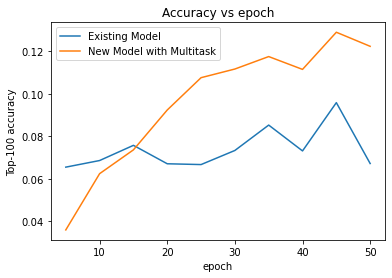

In [71]:
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-num_validation_runs:], label="Existing Model")
plt.plot(epochs, new_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="New Model with Multitask")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

In [72]:
accuracy = old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.0671.


In [73]:
accuracy = new_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.1223.


### Ranking-specialized model¶

In [74]:
ranking_weight = 1
retrieval_weight = 0

In [75]:
model = TwoTowers(candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight)

In [76]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate),
    run_eagerly=True)

In [77]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='total_loss', 
    patience=patience,
    verbose=1,
    restore_best_weights=True
)
new_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3704: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable.debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

In [78]:
new_model_history.history

{'root_mean_squared_error': [2.5177724361419678,
  1.7846859693527222,
  1.7445522546768188,
  1.7254951000213623,
  1.7142974138259888,
  1.7070361375808716,
  1.7020258903503418,
  1.698421597480774,
  1.6957453489303589,
  1.6936724185943604],
 'factorized_top_k/top_1_categorical_accuracy': [0.0035500000230968,
  0.0030499999411404133,
  0.0032250001095235348,
  0.0031624999828636646,
  0.0028750000055879354,
  0.003087500110268593,
  0.003100000089034438,
  0.003037499962374568,
  0.0029124999418854713,
  0.0030499999411404133],
 'factorized_top_k/top_5_categorical_accuracy': [0.016225000843405724,
  0.014562499709427357,
  0.014487500302493572,
  0.014512499794363976,
  0.014437500387430191,
  0.014637500047683716,
  0.014650000259280205,
  0.014624999836087227,
  0.01472499966621399,
  0.014487500302493572],
 'factorized_top_k/top_10_categorical_accuracy': [0.027512500062584877,
  0.02449999935925007,
  0.024250000715255737,
  0.02423750050365925,
  0.02408749982714653,
  0.02419

In [79]:
num_validation_runs = len(new_model_history.history["factorized_top_k/top_100_categorical_accuracy"])

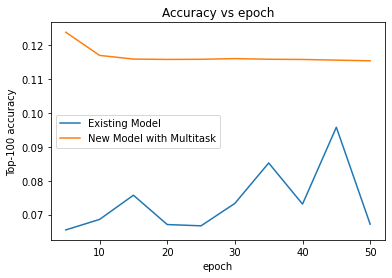

In [80]:
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-num_validation_runs:], label="Existing Model")
plt.plot(epochs, new_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="New Model with Multitask")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

### Joint model

In [81]:
ranking_weight = 1
retrieval_weight = 1

In [82]:
model = TwoTowers(candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight)

In [83]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate),
    run_eagerly=True)

In [84]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='total_loss', 
    patience=patience,
    verbose=1,
    restore_best_weights=True
)
new_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

In [85]:
new_model_history.history

{'root_mean_squared_error': [1.6958537101745605,
  1.696770191192627,
  1.6942362785339355,
  1.6951762437820435,
  1.6972769498825073,
  1.6939270496368408,
  1.6949118375778198,
  1.6926602125167847,
  1.6934387683868408,
  1.6909019947052002],
 'factorized_top_k/top_1_categorical_accuracy': [0.0036375001072883606,
  0.005375000182539225,
  0.0049749999307096004,
  0.006599999964237213,
  0.005862500052899122,
  0.006175000220537186,
  0.005425000097602606,
  0.0070374999195337296,
  0.005224999971687794,
  0.007449999917298555],
 'factorized_top_k/top_5_categorical_accuracy': [0.017937500029802322,
  0.02449999935925007,
  0.02381250075995922,
  0.029400000348687172,
  0.0272000003606081,
  0.030537499114871025,
  0.02617499977350235,
  0.03257500007748604,
  0.02526249922811985,
  0.03383750095963478],
 'factorized_top_k/top_10_categorical_accuracy': [0.029262499883770943,
  0.039787501096725464,
  0.039900001138448715,
  0.047337498515844345,
  0.04430000111460686,
  0.04904999956

In [86]:
num_validation_runs = len(new_model_history.history["factorized_top_k/top_100_categorical_accuracy"])

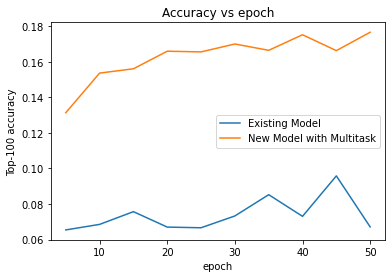

In [87]:
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-num_validation_runs:], label="Existing Model")
plt.plot(epochs, new_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="New Model with Multitask")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

In [88]:
accuracy = new_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.1766.


In [89]:
val_accuracy = new_model_history.history["val_factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {val_accuracy:.4f}.")

Top-100 accuracy: 0.0785.
